#### Step 8 - Random Forest
##### Input: X_train.npy, X_test.npy, y_train.npy, y_test.npy
##### Process: Train Random Forest classifier and evaluate
##### Output: Classification report and confusion matrix

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import joblib 
import os 

X_train = pd.read_csv('../Data/X_train.csv')
X_test = pd.read_csv('../Data/X_test.csv')
Y_train = np.load('../Data/Y_train.npy', allow_pickle=True)
Y_test = np.load('../Data/Y_test.npy', allow_pickle=True)

print("Data loaded")
print(f"X_train shape: {X_train.shape}")

Data loaded
X_train shape: (402698, 28)


In [2]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight={1: 15, 2: 3, 3: 1},
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=5,
    max_depth=20
)

model_rf.fit(X_train, Y_train)
print("Random Forest model trained")

Random Forest model trained


In [3]:
y_pred_rf = model_rf.predict(X_test)

print("First 10 predictions:", y_pred_rf[:10])
print("First 10 actual:     ", Y_test[:10])

First 10 predictions: [3 2 3 3 2 3 2 3 3 3]
First 10 actual:      [3 2 3 3 2 3 2 3 2 3]


In [4]:
print("Accuracy:", accuracy_score(Y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_rf, target_names=['Fatal','Serious','Slight']))

Accuracy: 0.7065110504097343

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.14      0.03      0.05      1497
     Serious       0.34      0.34      0.34     21991
      Slight       0.81      0.82      0.82     77187

    accuracy                           0.71    100675
   macro avg       0.43      0.40      0.40    100675
weighted avg       0.70      0.71      0.70    100675



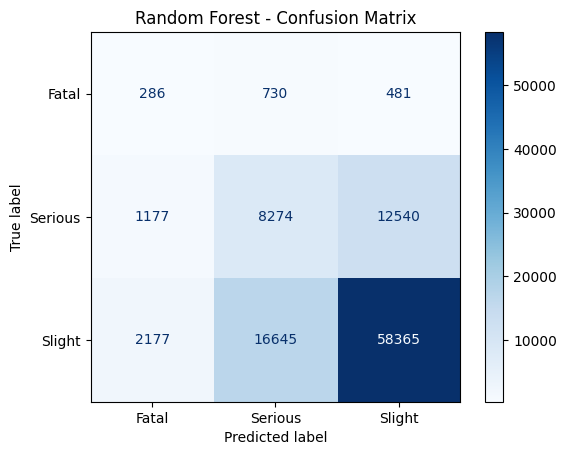

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    Y_test, y_pred_rf,
    display_labels=['Fatal','Serious','Slight'],
    cmap='Blues'
)
plt.title('Random Forest - Confusion Matrix')
plt.savefig('../Output/RF_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
print(pd.Series(Y_train).unique())

[2 3 1]


In [18]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, Y_train_res = smote.fit_resample(X_train, Y_train)

In [19]:
print("Before:", pd.Series(Y_train_mapped).value_counts().sort_index())
print("After:", pd.Series(Y_train_res).value_counts().sort_index())

Before: 0      5989
1     87961
2    308748
Name: count, dtype: int64
After: 0    308748
1    308748
2    308748
Name: count, dtype: int64


In [23]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
X_tr,X_val,Y_tr,Y_val = train_test_split(X_train_res,Y_train_res,test_size=0.2,random_state=42,stratify=Y_train_res)
model_xgb = XGBClassifier(
    n_estimators=3000,
    early_stopping_rounds=50,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    num_class=3,
    objective='multi:softprob',
    eval_metric='mlogloss'
)


In [24]:
model_xgb.fit(X_tr,Y_tr,eval_set=[(X_val,Y_val)],verbose=10)

[0]	validation_0-mlogloss:1.06833
[10]	validation_0-mlogloss:0.89774
[20]	validation_0-mlogloss:0.81743
[30]	validation_0-mlogloss:0.76363
[40]	validation_0-mlogloss:0.72662
[50]	validation_0-mlogloss:0.69723
[60]	validation_0-mlogloss:0.67318
[70]	validation_0-mlogloss:0.65619
[80]	validation_0-mlogloss:0.63731
[90]	validation_0-mlogloss:0.62468
[100]	validation_0-mlogloss:0.61241
[110]	validation_0-mlogloss:0.60087
[120]	validation_0-mlogloss:0.59165
[130]	validation_0-mlogloss:0.58208
[140]	validation_0-mlogloss:0.57427
[150]	validation_0-mlogloss:0.56673
[160]	validation_0-mlogloss:0.56002
[170]	validation_0-mlogloss:0.55353
[180]	validation_0-mlogloss:0.54742
[190]	validation_0-mlogloss:0.54155
[200]	validation_0-mlogloss:0.53703
[210]	validation_0-mlogloss:0.53178
[220]	validation_0-mlogloss:0.52692
[230]	validation_0-mlogloss:0.52319
[240]	validation_0-mlogloss:0.51899
[250]	validation_0-mlogloss:0.51522
[260]	validation_0-mlogloss:0.51255
[270]	validation_0-mlogloss:0.50907
[28

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegr

In [25]:
print("Best iteration:", model_xgb.best_iteration)
print("Best score:", model_xgb.best_score)

Best iteration: 2999
Best score: 0.36323042030145725


In [26]:
Y_pred_xgb = model_xgb.predict(X_test)

In [30]:
y_proba_xgb = model_xgb.predict_proba(X_test)
print("First 10 predicted probabilities:\n", y_proba_xgb[:10])
print("Mean predicted P(Fatal):", y_proba_xgb[:, 0].mean())
print("Max predicted P(Fatal):", y_proba_xgb[:, 0].max())

First 10 predicted probabilities:
 [[3.0111414e-04 6.8312943e-02 9.3138599e-01]
 [4.4827830e-02 4.8136929e-01 4.7380283e-01]
 [1.2000412e-06 3.3710799e-01 6.6289079e-01]
 [1.5193167e-04 1.2340820e-01 8.7643981e-01]
 [2.1501656e-03 3.8810933e-01 6.0974050e-01]
 [1.8331570e-04 1.8796623e-01 8.1185043e-01]
 [8.6509595e-03 4.8080999e-01 5.1053911e-01]
 [5.1504216e-04 1.9080321e-01 8.0868179e-01]
 [1.4584773e-03 2.8223452e-01 7.1630698e-01]
 [2.5592032e-03 2.3880722e-01 7.5863361e-01]]
Mean predicted P(Fatal): 0.014285979
Max predicted P(Fatal): 0.86685896


In [27]:
print(classification_report(Y_test, Y_pred_xgb, target_names=['Fatal','Serious','Slight']))

              precision    recall  f1-score   support

       Fatal       0.14      0.02      0.03      1497
     Serious       0.42      0.08      0.13     21991
      Slight       0.78      0.97      0.86     77187

    accuracy                           0.76    100675
   macro avg       0.45      0.36      0.34    100675
weighted avg       0.69      0.76      0.69    100675



In [32]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc
y_true_fatal  = (Y_test == 0).astype(int)
y_score_fatal = y_proba_xgb[:, 0]
precision, recall, thresholds = precision_recall_curve(y_true_fatal, y_score_fatal)
target_recall =0.6
valid_idx= np.where(recall >= target_recall)[0]
idx = valid_idx[-1]
print(f"Threshold for recall>={target_recall}: {thresholds[idx]:.4f}")
print(f"At that threshold — precision: {precision[idx]:.4f}, recall: {recall[idx]:.4f}")

Threshold for recall>=0.6: 0.0091
At that threshold — precision: 0.0349, recall: 0.6005


#### I prioritized catching fatal accidents over minimizing false alarms, since a missed fatal case is far more costly than a false flag

In [ ]:
os.makedirs('../Models', exist_ok=True)
joblib.dump(model_rf, '../Models/random_forest_model.pkl')

['../Models/random_forest_model.pkl']

In [ ]:
np.save('../Data/y_pred_rf.npy', y_pred_rf)

#### Random Forest Results Summary
- Random Forest uses 100 decision trees voting together
- n_jobs=-1 uses all CPU cores for faster training
- class_weight='balanced' handles the 83/15/2 imbalance
- Compare Fatal F1 score against Logistic Regression baseline
- Higher F1 for Fatal means Random Forest captures complex 
  non-linear patterns that Logistic Regression cannot